# Custom CNN — 50 epochs

Training and evaluation of a custom convolutional neural network for binary tuberculosis classification from chest X-ray images.

**Dataset path expected:** `data/TB_Chest_Radiography_Database/`.


Base directory contents: ['.ipynb_checkpoints', 'custom_cnn_tb.h5', 'file.pdf', 'file.png', 'main.py.py', 'Normal', 'Tuberculosis', 'Untitled.ipynb']
Data shape: (7000, 128, 128, 1)
Labels shape: (7000,)
Train data shape: (4900, 128, 128, 1), Train labels shape: (4900,)
Validation data shape: (1050, 128, 128, 1), Validation labels shape: (1050,)
Test data shape: (1050, 128, 128, 1), Test labels shape: (1050,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,821,121 (56.54 MB)

 Trainable params: 14,820,737 (56.54 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


154/154 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.7831 - loss: 12.9366 - val_accuracy: 0.5000 - val_loss: 35.2292 - learning_rate: 0.0010
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8239 - loss: 7.8044 - val_accuracy: 0.5705 - val_loss: 18.2505 - learning_rate: 0.0010
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.8476 - loss: 5.0949 - val_accuracy: 0.7152 - val_loss: 3.6252 - learning_rate: 0.0010
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8372 - loss: 2.8548 - val_accuracy: 0.7257 - val_loss: 2.1719 - learning_rate: 0.0010
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.8586 - loss: 1.9225 - val_accuracy: 0.9210 - val_loss: 1.0956 - learning_rate: 0.0010
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.8723 - loss: 1.1287 - val_accuracy: 0.8514 - val_loss: 0.9973 - learning_rate: 0.0010
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.8906 - loss: 0.8544 - v

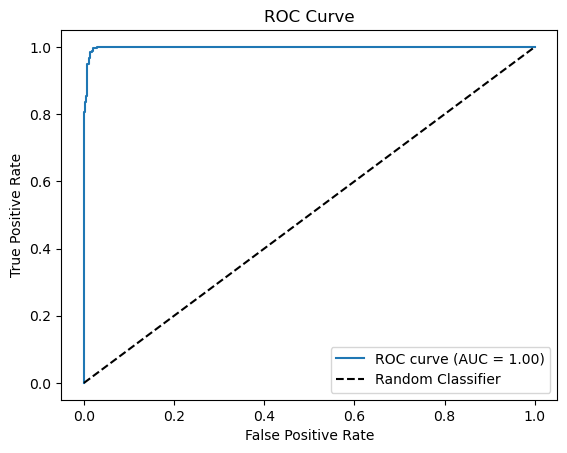

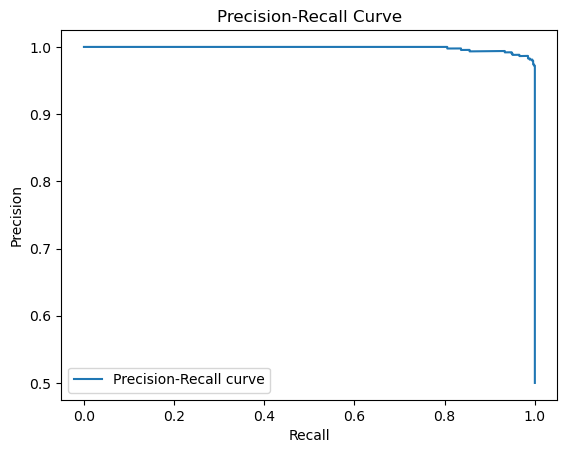

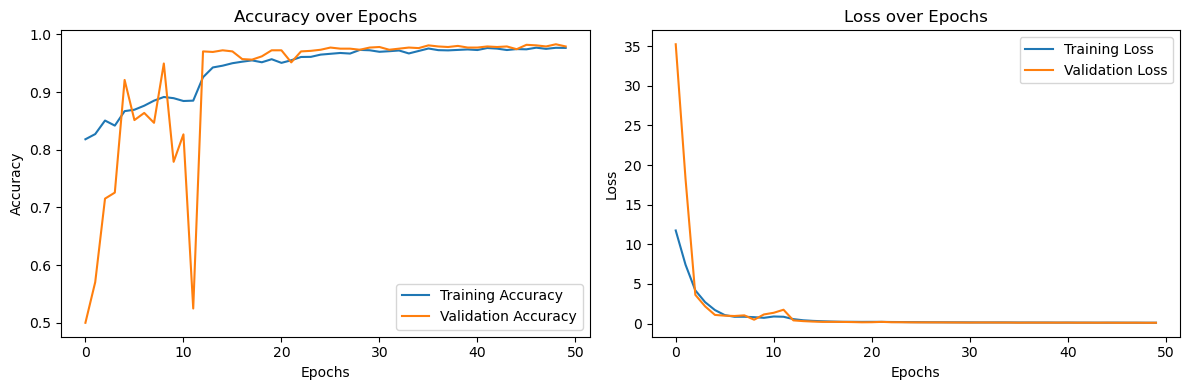

In [ ]:
#50 Epochs CNN

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2

# Step 1: Define base path
base_path = r'data/TB_Chest_Radiography_Database'

# Check base directory contents
print("Base directory contents:", os.listdir(base_path))

# Step 2: Load and preprocess the data
img_size = 128  # Resize images to 128x128

def load_images(base_path, img_size):
    data = []
    labels = []
    categories = ['Normal', 'Tuberculosis']  # Class names
    
    for category in categories:
        path = os.path.join(base_path, category)
        class_label = categories.index(category)  # Assign 0 or 1 as label
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image: {e}")
    
    return np.array(data), np.array(labels)

# ######Load data and labels
data, labels = load_images(base_path, img_size)
data = data / 255.0  # Normalize pixel values to [0, 1]

# Reshape data to fit the model input requirements (128, 128, 1)
data = data.reshape(-1, img_size, img_size, 1)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# Step 3: Split the dataset into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Step 4: Data Augmentation
data_generator = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

data_generator.fit(X_train)

# #######Step 5: Build the CNN model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 7: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Step 9: Classification Report and Confusion Matrix
print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

###### Step 10: ROC and Precision-Recall Curves
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

###### Step 11: Training and Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [2]:
# Save the trained model
model.save('tb_cnn7000_model.h5')
print("Model saved successfully as tb_cnn_model.h5")


Model saved successfully as tb_cnn_model.h5


In [3]:
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Loss: 0.0875
Test Accuracy: 98.48%


33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 680ms/step
Confusion Matrix:
 [[511  14]
 [  2 523]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98       525
           1       0.97      1.00      0.98       525

    accuracy                           0.98      1050
   macro avg       0.99      0.98      0.98      1050
weighted avg       0.99      0.98      0.98      1050



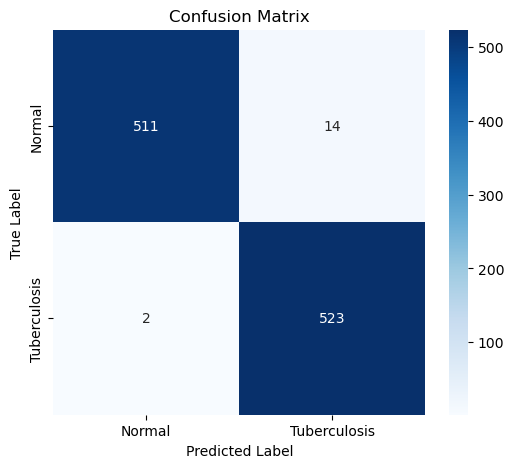

In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)  # Convert probabilities to binary classes

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Print confusion matrix and classification report
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_classes))

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Tuberculosis'], yticklabels=['Normal', 'Tuberculosis'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [5]:
pip install fastapi uvicorn tensorflow numpy pillow nest_asyncio


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
Try API
import numpy as np
import tensorflow as tf
from fastapi import FastAPI, File, UploadFile
from tensorflow.keras.models import load_model
from fastapi.responses import JSONResponse
import uvicorn
from io import BytesIO
from PIL import Image

# #####Initialize FastAPI app
app = FastAPI(title="TB Classification API", description="Upload a chest X-ray image to detect tuberculosis.", version="1.0")

# Load the trained CNN model
MODEL_PATH = "tb_cnn_model.h5"
model = load_model(MODEL_PATH)

# Define image size for CNN model
IMG_SIZE = 128

# Function to preprocess the image
def preprocess_image(image_data):
    img = Image.open(BytesIO(image_data)).convert("L") 
    img = img.resize((IMG_SIZE, IMG_SIZE))  
    img_array = np.array(img) / 255.0 
    img_array = np.expand_dims(img_array, axis=0) 
    img_array = np.expand_dims(img_array, axis=-1)  
    return img_array

# #####Home route
@app.get("/")
def home():
    return {"message": "Welcome to the TB Classification API!"}

# Prediction route
@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    try:
        # Read uploaded file and preprocess it
        image_data = await file.read()
        img_array = preprocess_image(image_data)

        # Make prediction
        prediction = model.predict(img_array)
        confidence = float(prediction[0][0])

        # Determine class label
        result = "Tuberculosis Detected" if confidence > 0.5 else "Normal"

        return JSONResponse(content={"diagnosis": result, "confidence": confidence})

    except Exception as e:
        return JSONResponse(content={"error": str(e)}, status_code=500)

# Run API with Uvicorn
if __name__ == "__main__":
    import nest_asyncio
    nest_asyncio.apply()
    uvicorn.run(app, host="0.0.0.0", port=8006)


INFO:     Started server process [12892]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8006 (Press CTRL+C to quit)


INFO:     127.0.0.1:50697 - "GET /predict HTTP/1.1" 405 Method Not Allowed
INFO:     127.0.0.1:50697 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:50706 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:50706 - "GET /openapi.json HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step
INFO:     127.0.0.1:50711 - "POST /predict HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [12892]
